# Hasta cuatro kilómetros de película que tiene color sin llevar pigmento

El rojo de esta película no está pintado. Está construido.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Li et al. (2026), *Monomer-biased manufacture of industrial-scale colloidal photonic films*, **Science**
**DOI:** [10.1126/science.aed8723](https://doi.org/10.1126/science.aed8723)
**Datos:** Supplementary Materials del mismo DOI (Tablas S1–S2, figs. S4, S5, S24, S54)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-04-peliculas-fotonicas-industriales/notebook.ipynb)

**Video:** [Pendiente]

## De dónde sale el color

Las alas de un morpho no tienen pigmento azul. Tienen capas ordenadas a escala nanométrica que
devuelven el azul y dejan pasar el resto. Eso es color estructural: el color lo pone la geometría,
no la química del tinte. No se destiñe con el sol, porque no hay molécula que se degrade.

Copiarlo en el laboratorio se sabe hacer desde hace años. Se apilan partículas de plástico
—todas del mismo tamaño— hasta que se acomodan solas en una rejilla, un cristal fotónico coloidal.
El problema nunca fue hacerlo: fue hacerlo **grande y rápido**. Ordenar esas partículas cuesta
energía, y la ruta habitual es calentar y esperar. Eso no cabe en una línea de producción.

Lo que hizo este equipo fue meter monómeros comunes como mediadores: moléculas pequeñas que bajan
la barrera energética y sesgan el camino de ensamblado, de modo que el simple cizallamiento de
untar la mezcla sobre una lámina alcanza para ordenarla, a temperatura ambiente y en segundos.
Con eso lo llevaron a una línea de rollo a rollo (roll-to-roll), la misma idea de una imprenta de
periódico: la lámina avanza sin parar de una bobina a otra.

Veamos qué tan lejos llega eso, y dónde los datos del suplementario se ponen incómodos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
LAMBDA_REPOSO = 650          # nm — pico de reflexión de la prenda en reposo (fig. S54B)
VENTANA_SIM_NM = (14, 42)    # nm — ventana de espesor de coraza que la simulación de dinámica
                             #      molecular (RNEMD) marca
                             #      como favorable al ordenamiento (fig. S5)
PDI_MONODISPERSO = 0.1       # convención DLS: por debajo de 0,1 se considera monodisperso

def num(x, d=1):
    # Formato numérico español: coma decimal.
    return ('{:.' + str(d) + 'f}').format(x).replace('.', ',')


FUENTE = ('Fuente: Li et al. (2026), Science | '
          'Datos: Supplementary Materials del mismo DOI')

COLOR_DATOS = '#2563EB'        # azul CaM — dato principal
COLOR_ALERTA = '#DC2626'       # rojo — este trabajo / contraste
COLOR_SECUNDARIO = '#059669'   # verde — serie secundaria
COLOR_REFERENCIA = '#D97706'   # ámbar — umbral / referencia
COLOR_CONTEXTO = '#BBBBBB'     # gris — contexto

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en el repo → fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(BASE + '/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga de los cuatro CSV transcritos del Supplementary ──
dls = pd.read_csv('datos/particulas_dls.csv')        # Tabla S1
dt = pd.read_csv('datos/dls_vs_tem.csv')             # Tabla S1 + fig. S24
met = pd.read_csv('datos/comparacion_metodos.csv')   # Tabla S2
mec = pd.read_csv('datos/mecanocromismo.csv')        # fig. S54B

etiqueta_escala = {1: 'cm', 2: 'dm', 3: 'm', 4: 'km'}

print('Formulaciones industriales:', dls.formulacion.nunique(),
      '| etapas por formulación:', dls.etapa.nunique())
print('PDI: rango {}–{} — {}/{} por debajo de {}'.format(
    num(dls.pdi.min(), 2), num(dls.pdi.max(), 2),
    int((dls.pdi < PDI_MONODISPERSO).sum()), len(dls), num(PDI_MONODISPERSO, 1)))
print()
final = dls[dls.etapa == 'coraza'].set_index('formulacion')
for f in ['S-1', 'S-2', 'S-3']:
    print('  {}: SDS {} % → {} nm de diámetro final'.format(
        f, num(final.loc[f, 'sds_wt_pct'], 3), num(final.loc[f, 'diametro_z_nm'], 1)))
print()
print('Métodos comparados en la Tabla S2:', len(met), '(7 previos + este trabajo)')
print('Métodos previos que YA trabajaban a 25 °C:',
      ', '.join(met[(met.es_este_trabajo == 0) & (met.temperatura_c == 25)].metodo.tolist()))

Formulaciones industriales: 3 | etapas por formulación: 3
PDI: rango 0,01–0,05 — 9/9 por debajo de 0,1

  S-1: SDS 0,073 % → 223,0 nm de diámetro final
  S-2: SDS 0,060 % → 243,0 nm de diámetro final
  S-3: SDS 0,044 % → 282,1 nm de diámetro final

Métodos comparados en la Tabla S2: 8 (7 previos + este trabajo)
Métodos previos que YA trabajaban a 25 °C: BIST, CLC, SSAT


Aquí está.

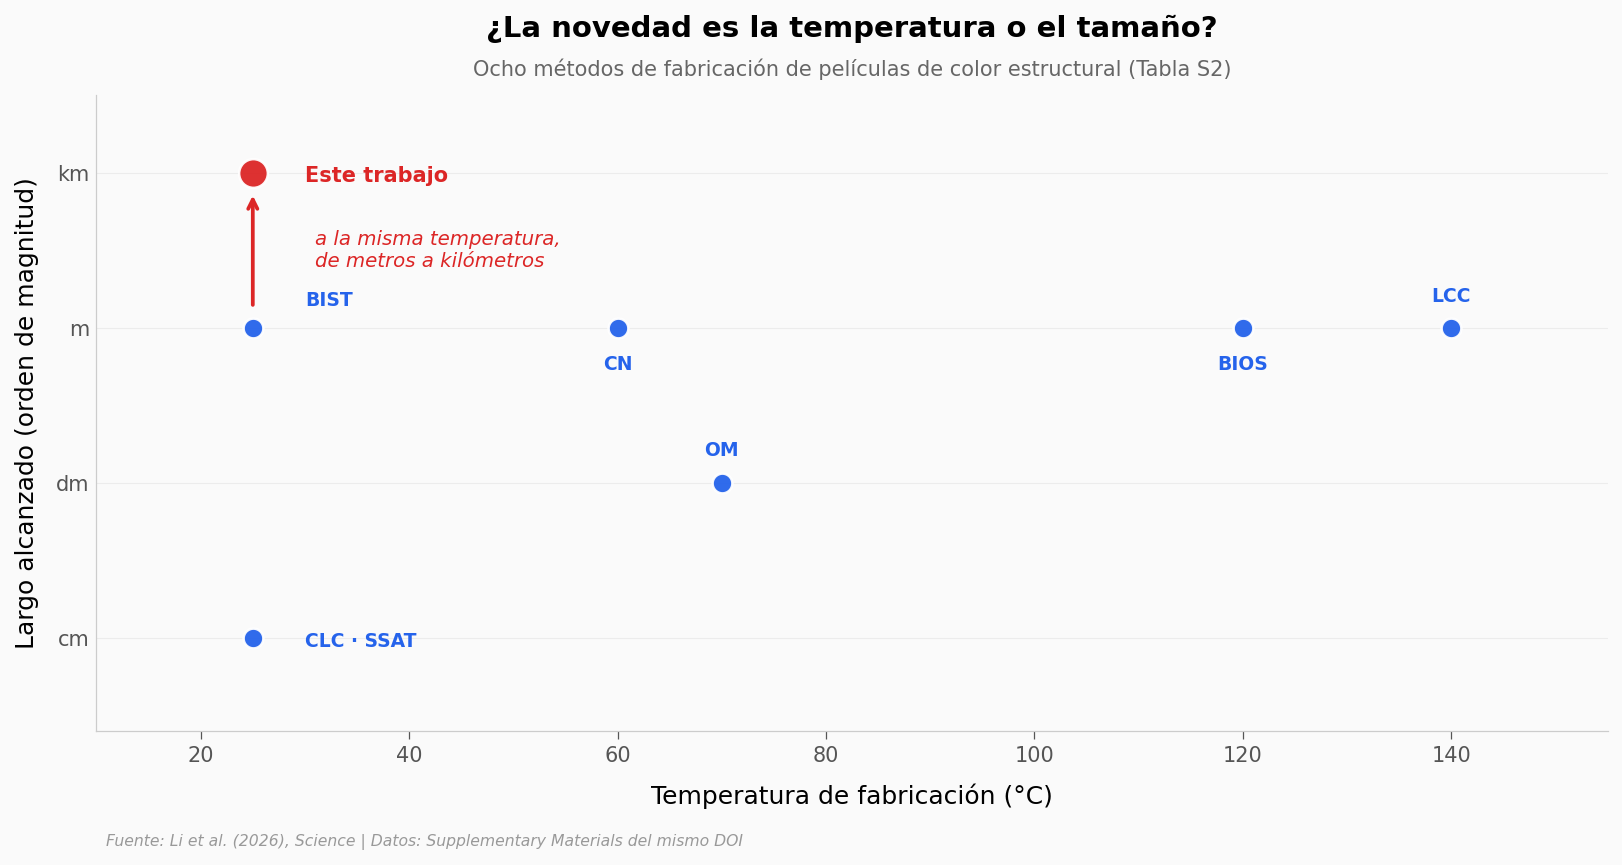

Métodos previos: 7 | a 25 °C: 3 (BIST, CLC, SSAT)
Temperatura más alta entre los previos: 140 °C (LCC)
Largo máximo previo: m | este trabajo: km
Ancho máximo previo: dm | este trabajo: m


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Varios métodos comparten exactamente (temperatura, escala): se agrupan para no
# apilar dos rótulos encima del mismo punto.
grupos = (met.groupby(['temperatura_c', 'orden_largo', 'es_este_trabajo'])['metodo']
             .apply(lambda s: ' · '.join(sorted(s)))
             .reset_index())

for _, r in grupos.iterrows():
    es_este = r.es_este_trabajo == 1
    ax.scatter(r.temperatura_c, r.orden_largo,
               color=COLOR_ALERTA if es_este else COLOR_DATOS,
               s=190 if es_este else 90, alpha=0.95,
               edgecolors='white', linewidths=1.2, zorder=6)

# Desplazamientos de rótulo elegidos a mano: pares cercanos en x se separan en y.
offsets = {'LCC': (0, 0.17, 'center'), 'BIOS': (0, -0.27, 'center'),
           'BIST': (5, 0.14, 'left'), 'OM': (0, 0.17, 'center'),
           'CN': (0, -0.27, 'center'), 'CLC · SSAT': (5, -0.06, 'left'),
           'Este trabajo': (5, -0.06, 'left')}
for _, r in grupos.iterrows():
    dx, dy, ha = offsets[r.metodo]
    ax.text(r.temperatura_c + dx, r.orden_largo + dy, r.metodo,
            fontsize=10 if r.es_este_trabajo == 1 else 9, ha=ha,
            fontweight='bold',
            color=COLOR_ALERTA if r.es_este_trabajo == 1 else COLOR_DATOS)

# El salto ocurre SIN moverse de los 25 °C.
ax.annotate('', xy=(25, 3.88), xytext=(25, 3.12),
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.8))
ax.text(31, 3.5, 'a la misma temperatura,\nde metros a kilómetros',
        fontsize=9.5, color=COLOR_ALERTA, va='center', style='italic')

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels([etiqueta_escala[i] for i in [1, 2, 3, 4]])
ax.set_ylim(0.4, 4.5)
ax.set_xlim(10, 155)
ax.set_xlabel('Temperatura de fabricación (°C)')
ax.set_ylabel('Largo alcanzado (orden de magnitud)')
ax.set_title('¿La novedad es la temperatura o el tamaño?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ocho métodos de fabricación de películas de color estructural (Tabla S2)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escala_vs_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

previos = met[met.es_este_trabajo == 0]
a25 = previos[previos.temperatura_c == 25]
print('Métodos previos: {} | a 25 °C: {} ({})'.format(
    len(previos), len(a25), ', '.join(a25.metodo)))
print('Temperatura más alta entre los previos: {} °C ({})'.format(
    previos.temperatura_c.max(), previos.loc[previos.temperatura_c.idxmax(), 'metodo']))
print('Largo máximo previo: {} | este trabajo: {}'.format(
    etiqueta_escala[previos.orden_largo.max()],
    etiqueta_escala[int(met[met.es_este_trabajo == 1].orden_largo.iloc[0])]))
print('Ancho máximo previo: {} | este trabajo: {}'.format(
    etiqueta_escala[previos.orden_ancho.max()],
    etiqueta_escala[int(met[met.es_este_trabajo == 1].orden_ancho.iloc[0])]))

## Lo que llama la atención

Tres de los siete métodos previos —BIST, CLC y SSAT— ya fabricaban a 25 °C. La temperatura ambiente
no es la novedad, y conviene decirlo antes de que un titular la convierta en el titular.

Lo que ninguno había hecho es llegar a esa escala sin calentar. Los cuatro métodos que alcanzaban
el orden de los metros de largo chocaron todos contra el mismo techo —metros de largo, decímetros
de ancho—, calentaran o no: LCC a 140 °C, BIOS a 120 °C y CN a 60 °C llegaron exactamente adonde
llegó BIST a 25 °C. El calor no compró escala. Este trabajo se queda en el
mismo punto del eje horizontal y sube un escalón completo en el vertical: de metros a kilómetros
de largo, y de decímetros a metros de ancho.

Y la escala tiene un número asociado que no sale de esta gráfica sino del abstract: **4.000 metros
de largo por 1,3 metros de ancho**, a 25 metros por minuto. Es capacidad demostrada en línea, no
producción comercial en curso — el paper dice *can be produced up to*, y esa diferencia importa.

## Antes de la película, la partícula

Nada de esto funciona si las esferas no son casi idénticas: una rejilla ordenada necesita ladrillos
del mismo tamaño. La Tabla S1 sigue las tres formulaciones industriales (S-1, S-2, S-3) por las
tres etapas de síntesis —semilla, núcleo y coraza— y deja ver de dónde sale el tamaño final. La
columna que cambia entre formulaciones es el SDS: el surfactante —un jabón— de la receta.

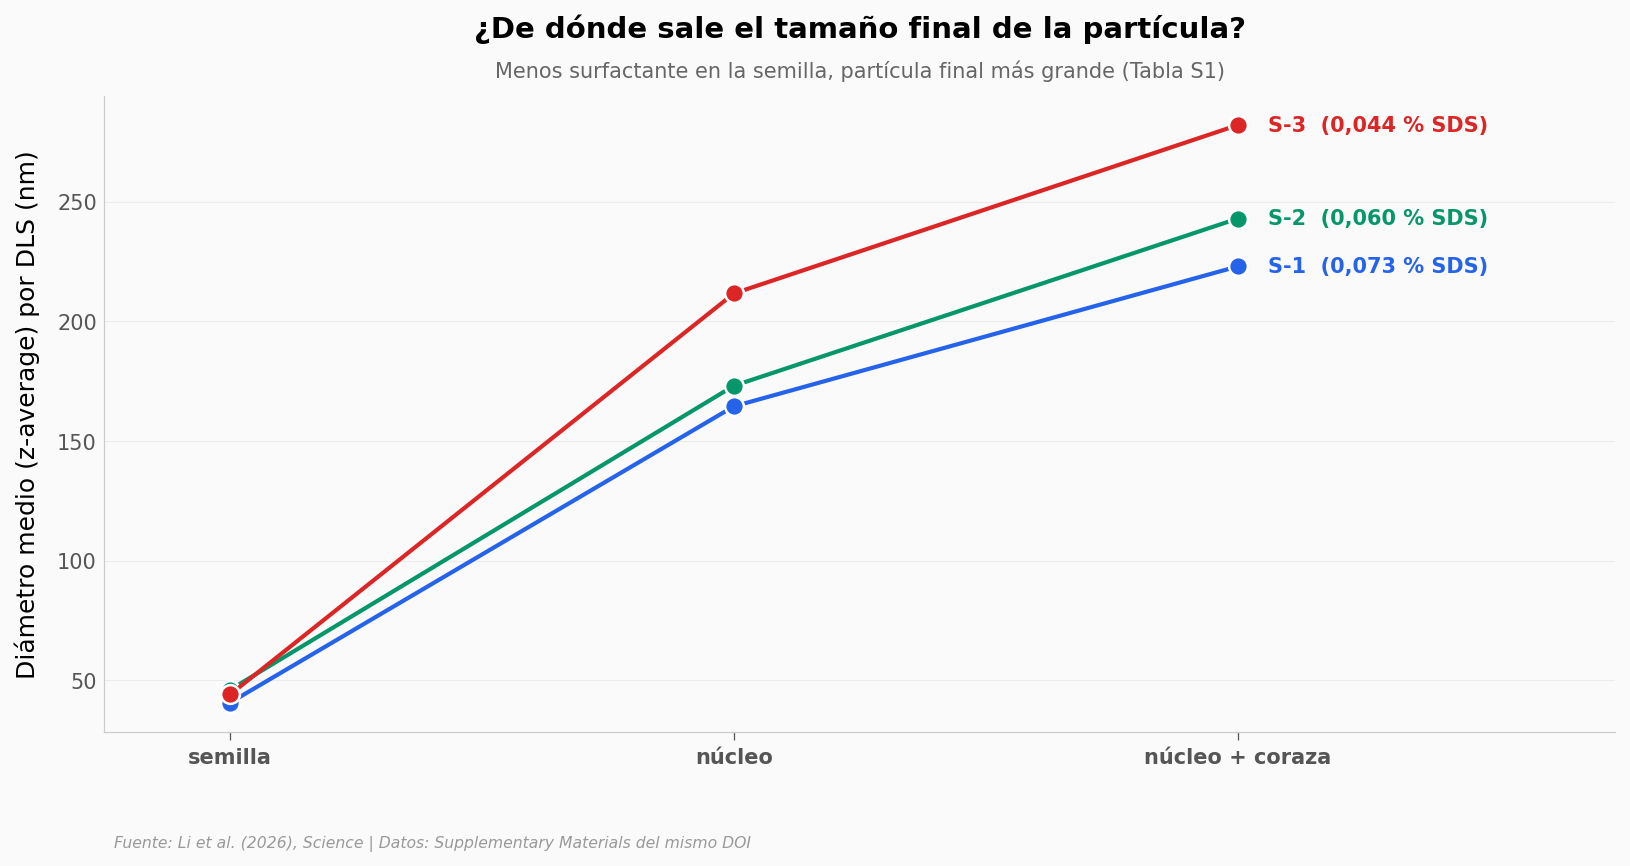

SDS de la semilla → diámetro final:
   0,044 % → 282,1 nm
   0,060 % → 243,0 nm
   0,073 % → 223,0 nm
Relación monótona en las 3 formulaciones: True (n = 3, sin réplicas)

Espesor radial de coraza por DLS: 29,25 · 34,95 · 35,20 nm — media 33,13 nm
PDI de las 9 medidas: 0,01–0,05 (convención de monodispersidad: < 0,1)


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

orden_etapas = ['semilla', 'nucleo', 'coraza']
nombres_etapas = ['semilla', 'núcleo', 'núcleo + coraza']
colores_form = {'S-1': COLOR_DATOS, 'S-2': COLOR_SECUNDARIO, 'S-3': COLOR_ALERTA}

for f in ['S-1', 'S-2', 'S-3']:
    sub = dls[dls.formulacion == f].set_index('etapa').loc[orden_etapas]
    x = np.arange(len(orden_etapas))
    ax.plot(x, sub.diametro_z_nm, color=colores_form[f], lw=2, marker='o',
            markersize=9, markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    sds = sub.sds_wt_pct.iloc[0]
    ax.text(x[-1] + 0.06, sub.diametro_z_nm.iloc[-1],
            '{}  ({:.3f} % SDS)'.format(f, sds).replace('.', ','),
            fontsize=10, fontweight='bold', color=colores_form[f], va='center')

ax.set_xticks(np.arange(len(orden_etapas)))
ax.set_xticklabels(nombres_etapas, fontsize=10, fontweight='bold')
ax.set_xlim(-0.25, 2.75)
ax.set_ylabel('Diámetro medio (z-average) por DLS (nm)')
ax.set_title('¿De dónde sale el tamaño final de la partícula?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Menos surfactante en la semilla, partícula final más grande (Tabla S1)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/crecimiento_particulas.png', dpi=200, bbox_inches='tight')
plt.show()

orden_sds = final.sort_values('sds_wt_pct')
print('SDS de la semilla → diámetro final:')
for f, r in orden_sds.iterrows():
    print('   {} % → {} nm'.format(num(r.sds_wt_pct, 3), num(r.diametro_z_nm, 1)))
monotono = bool((np.diff(orden_sds.diametro_z_nm.values) < 0).all())
print('Relación monótona en las 3 formulaciones:', monotono, '(n = 3, sin réplicas)')
print()
print('Espesor radial de coraza por DLS: {} nm — media {} nm'.format(
    ' · '.join(num(v, 2) for v in final.incremento_radio_nm),
    num(final.incremento_radio_nm.mean(), 2)))
print('PDI de las 9 medidas: {}–{} (convención de monodispersidad: < {})'.format(
    num(dls.pdi.min(), 2), num(dls.pdi.max(), 2), num(PDI_MONODISPERSO, 1)))

## Dos reglas que no miden lo mismo

Hasta aquí todo cuadra. Pero el suplementario mide esas partículas dos veces y con dos instrumentos
distintos: dispersión de luz en agua (DLS, la Tabla S1) y conteo sobre imágenes de microscopía
(la fig. S24). Cuando ponemos los dos números lado a lado aparece algo que el paper no comenta.

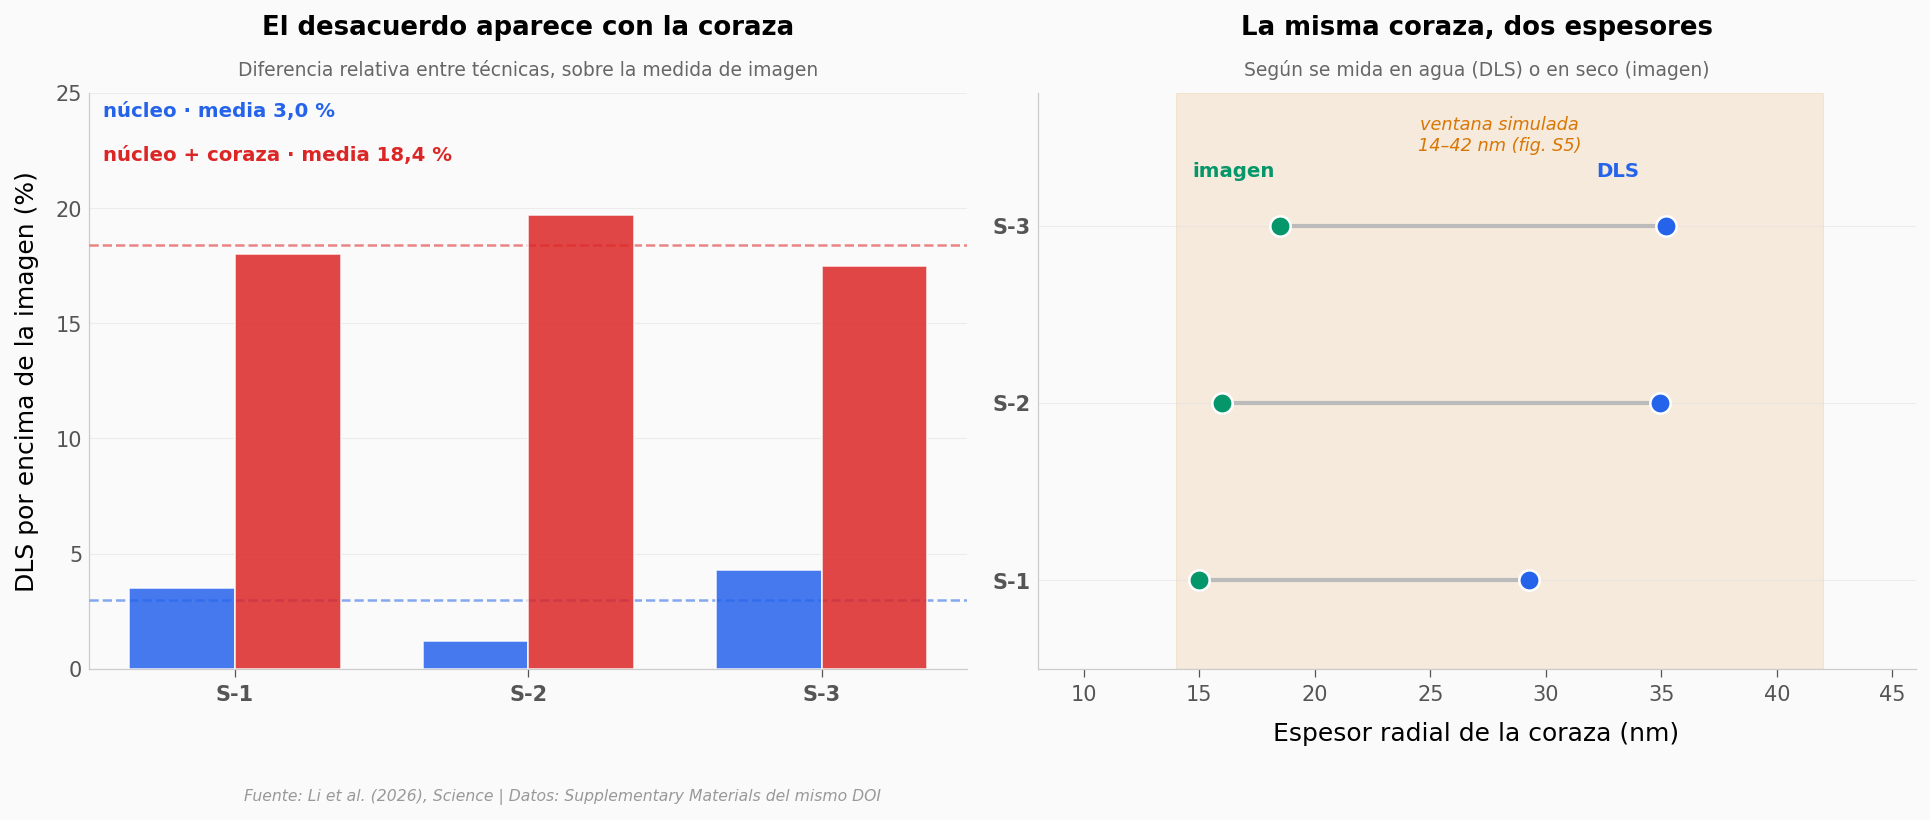

Desacuerdo en el núcleo:         media 3,0 % (rango 1,2–4,3)
Desacuerdo con la coraza puesta: media 18,4 % (rango 17,5–19,7)
Se multiplica por 6,1 al pasar de uno a otro

Espesor de coraza — DLS:    29,25 · 34,95 · 35,20 nm (media 33,1)
Espesor de coraza — imagen: 15,0 · 16,0 · 18,5 nm (media 16,5)
La coraza medida en agua es 2,0 veces la medida en seco
Dentro de la ventana simulada — DLS: 3/3 | imagen: 3/3


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

# ── Panel izquierdo: desacuerdo relativo entre técnicas, por etapa ──
# dif_pct del CSV está expresado sobre la medida de imagen (verificado por recálculo).
ancho = 0.36
x = np.arange(3)
for i, (etapa, nombre, color) in enumerate(
        [('nucleo', 'núcleo', COLOR_DATOS), ('coraza', 'núcleo + coraza', COLOR_ALERTA)]):
    sub = dt[dt.etapa == etapa].set_index('formulacion').loc[['S-1', 'S-2', 'S-3']]
    ax1.bar(x + (i - 0.5) * ancho, sub.dif_pct, ancho, color=color, alpha=0.85,
            edgecolor='white', linewidth=0.8, zorder=5)
    media = sub.dif_pct.mean()
    ax1.axhline(y=media, color=color, lw=1.2, linestyle='--', alpha=0.55, zorder=4)
    ax1.text(-0.45, 24.2 - i * 1.9,
             '{} · media {:.1f} %'.format(nombre, media).replace('.', ','),
             fontsize=9.5, fontweight='bold', color=color, ha='left', va='center')

ax1.set_xticks(x)
ax1.set_xticklabels(['S-1', 'S-2', 'S-3'], fontsize=10, fontweight='bold')
ax1.set_ylabel('DLS por encima de la imagen (%)')
ax1.set_ylim(0, 25)
ax1.set_title('El desacuerdo aparece con la coraza', fontsize=12.5, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Diferencia relativa entre técnicas, sobre la medida de imagen',
         transform=ax1.transAxes, fontsize=9, color='#666666', ha='center')

# ── Panel derecho: espesor de coraza según quién lo mida ──
nucleo = dt[dt.etapa == 'nucleo'].set_index('formulacion')
coraza = dt[dt.etapa == 'coraza'].set_index('formulacion')
forms = ['S-1', 'S-2', 'S-3']
y = np.arange(3)
ax2.axvspan(VENTANA_SIM_NM[0], VENTANA_SIM_NM[1], color=COLOR_REFERENCIA,
            alpha=0.12, zorder=1)
ax2.text(np.mean(VENTANA_SIM_NM), 2.62,
         'ventana simulada\n{}–{} nm (fig. S5)'.format(*VENTANA_SIM_NM),
         fontsize=8.5, color=COLOR_REFERENCIA, ha='center', va='top', style='italic')

for i, f in enumerate(forms):
    e_dls = (coraza.loc[f, 'diametro_dls_nm'] - nucleo.loc[f, 'diametro_dls_nm']) / 2
    e_img = (coraza.loc[f, 'diametro_tem_nm'] - nucleo.loc[f, 'diametro_tem_nm']) / 2
    ax2.plot([e_img, e_dls], [i, i], color=COLOR_CONTEXTO, lw=2, zorder=3)
    ax2.scatter(e_img, i, color=COLOR_SECUNDARIO, s=95, edgecolors='white',
                linewidths=1.2, zorder=6)
    ax2.scatter(e_dls, i, color=COLOR_DATOS, s=95, edgecolors='white',
                linewidths=1.2, zorder=6)

ax2.text(16.5, 2.28, 'imagen', fontsize=9.5, fontweight='bold',
         color=COLOR_SECUNDARIO, ha='center')
ax2.text(33.1, 2.28, 'DLS', fontsize=9.5, fontweight='bold',
         color=COLOR_DATOS, ha='center')
ax2.set_yticks(y)
ax2.set_yticklabels(forms, fontsize=10, fontweight='bold')
ax2.set_ylim(-0.5, 2.75)
ax2.set_xlim(8, 46)
ax2.set_xlabel('Espesor radial de la coraza (nm)')
ax2.set_title('La misma coraza, dos espesores', fontsize=12.5, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Según se mida en agua (DLS) o en seco (imagen)',
         transform=ax2.transAxes, fontsize=9, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/dls_vs_imagen.png', dpi=200, bbox_inches='tight')
plt.show()

g_nuc = dt[dt.etapa == 'nucleo'].dif_pct
g_cor = dt[dt.etapa == 'coraza'].dif_pct
print('Desacuerdo en el núcleo:         media {} % (rango {}–{})'.format(
    num(g_nuc.mean()), num(g_nuc.min()), num(g_nuc.max())))
print('Desacuerdo con la coraza puesta: media {} % (rango {}–{})'.format(
    num(g_cor.mean()), num(g_cor.min()), num(g_cor.max())))
print('Se multiplica por {} al pasar de uno a otro'.format(num(g_cor.mean() / g_nuc.mean())))
print()
esp_dls = ((coraza.diametro_dls_nm - nucleo.diametro_dls_nm) / 2)
esp_img = ((coraza.diametro_tem_nm - nucleo.diametro_tem_nm) / 2)
print('Espesor de coraza — DLS:    {} nm (media {})'.format(
    ' · '.join(num(v, 2) for v in esp_dls), num(esp_dls.mean())))
print('Espesor de coraza — imagen: {} nm (media {})'.format(
    ' · '.join(num(v, 1) for v in esp_img), num(esp_img.mean())))
print('La coraza medida en agua es {} veces la medida en seco'.format(
    num(esp_dls.mean() / esp_img.mean())))
dentro_dls = int(((esp_dls >= VENTANA_SIM_NM[0]) & (esp_dls <= VENTANA_SIM_NM[1])).sum())
dentro_img = int(((esp_img >= VENTANA_SIM_NM[0]) & (esp_img <= VENTANA_SIM_NM[1])).sum())
print('Dentro de la ventana simulada — DLS: {}/3 | imagen: {}/3'.format(dentro_dls, dentro_img))

## Eso es raro

En el núcleo desnudo las dos técnicas se llevan bien: **3,0 %** de diferencia promedio (el DLS por
encima de la imagen, que es la base de todos los porcentajes de esta sección), dentro de lo
que uno espera de dos instrumentos distintos. Al añadir la coraza el desacuerdo se dispara a
**18,4 %** — se multiplica por seis. Y si en vez de comparar diámetros completos se compara solo el
espesor de la coraza, la brecha deja de ser un matiz: **33,1 nm medidos en agua contra 16,5 nm
medidos en seco**, el doble.

La lectura natural es que la coraza es polimérica y está hinchada de agua cuando el DLS la mide,
y colapsada cuando la microscopía la ve seca. Es una explicación razonable y **es nuestra, no del
paper**: el suplementario publica los dos números y no los reconcilia.

Esto importa porque el paper también publica una simulación (fig. S5) que marca una ventana de
espesor de coraza favorable al ordenamiento, de 14 a 42 nm, y no dice a cuál de las dos medidas se
refiere. Con el espesor por DLS, las tres formulaciones caen cómodamente dentro. Con el de imagen,
caen pegadas al borde inferior. Cuál de las dos lecturas es la correcta cambia si la ventana está
holgada o justa — y el material accesible no alcanza para decidirlo. Es coherencia, no validación.

Queda una cosa más, y es la que se ve sin instrumentos.

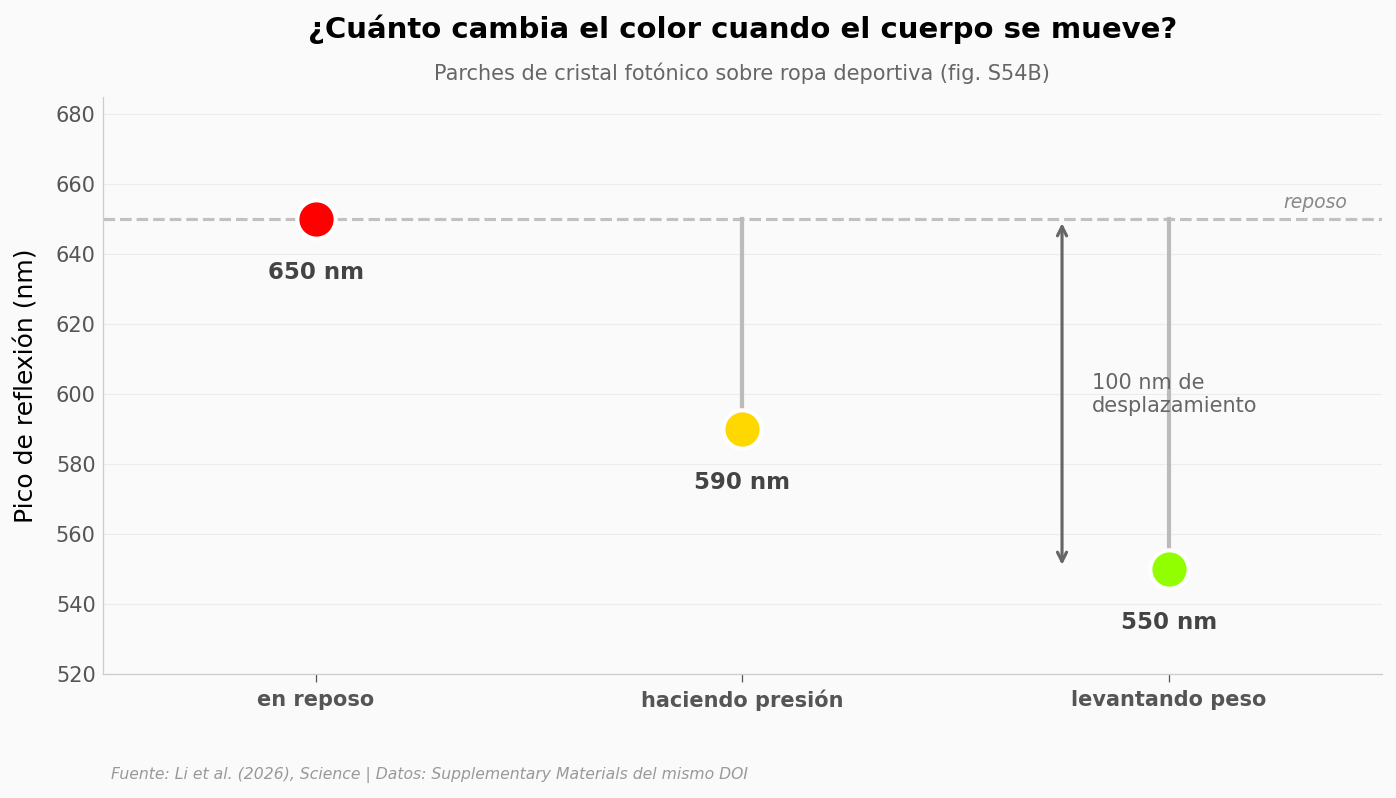

     en reposo: 650 nm  (Δ frente al reposo: +0 nm)
haciendo presión: 590 nm  (Δ frente al reposo: -60 nm)
levantando peso: 550 nm  (Δ frente al reposo: -100 nm)

Desplazamiento total del pico: 100 nm (650 → 550)


In [5]:
# Cierre comparativo en vez de histograma: son tres estados discretos medidos, no
# una distribución muestreada (regla 6 — excepción benchmark).
def color_de_onda(nm):
    # Aproximación visual del color asociado a una longitud de onda, en RGB.
    if nm < 440:
        r, g, b = -(nm - 440) / 60.0, 0.0, 1.0
    elif nm < 490:
        r, g, b = 0.0, (nm - 440) / 50.0, 1.0
    elif nm < 510:
        r, g, b = 0.0, 1.0, -(nm - 510) / 20.0
    elif nm < 580:
        r, g, b = (nm - 510) / 70.0, 1.0, 0.0
    elif nm < 645:
        r, g, b = 1.0, -(nm - 645) / 65.0, 0.0
    else:
        r, g, b = 1.0, 0.0, 0.0
    return (max(0.0, min(1.0, r)), max(0.0, min(1.0, g)), max(0.0, min(1.0, b)))

fig, ax = plt.subplots(figsize=(11, 5))
etiquetas = {'quieto': 'en reposo', 'presion': 'haciendo presión',
             'levantamiento': 'levantando peso'}
mec_ord = mec.set_index('movimiento').loc[['quieto', 'presion', 'levantamiento']]
x = np.arange(len(mec_ord))

ax.axhline(y=LAMBDA_REPOSO, color=COLOR_CONTEXTO, linewidth=1.5, linestyle='--',
           alpha=0.9, zorder=2)
ax.text(2.42, LAMBDA_REPOSO + 2, 'reposo', fontsize=9, color='#888888',
        ha='right', va='bottom', style='italic')

for i, (mov, r) in enumerate(mec_ord.iterrows()):
    ax.plot([i, i], [LAMBDA_REPOSO, r.lambda_central_nm], color=COLOR_CONTEXTO,
            lw=2, zorder=3)
    ax.scatter(i, r.lambda_central_nm, color=color_de_onda(r.lambda_central_nm),
               s=340, edgecolors='white', linewidths=2, zorder=6)
    ax.text(i, r.lambda_central_nm - 12, '{} nm'.format(int(r.lambda_central_nm)),
            fontsize=11, fontweight='bold', ha='center', va='top', color='#444444')

salto = int(mec_ord.lambda_central_nm.max() - mec_ord.lambda_central_nm.min())
ax.annotate('', xy=(1.75, mec_ord.lambda_central_nm.min()),
            xytext=(1.75, mec_ord.lambda_central_nm.max()),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(1.82, (mec_ord.lambda_central_nm.min() + mec_ord.lambda_central_nm.max()) / 2,
        '{} nm de\ndesplazamiento'.format(salto), fontsize=10, color='#666666', va='center')

ax.set_xticks(x)
ax.set_xticklabels([etiquetas[m] for m in mec_ord.index], fontsize=10, fontweight='bold')
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(520, 685)
ax.set_ylabel('Pico de reflexión (nm)')
ax.set_title('¿Cuánto cambia el color cuando el cuerpo se mueve?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Parches de cristal fotónico sobre ropa deportiva (fig. S54B)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mecanocromismo.png', dpi=200, bbox_inches='tight')
plt.show()

for mov, r in mec_ord.iterrows():
    print('{:>14}: {} nm  (Δ frente al reposo: {:+d} nm)'.format(
        etiquetas[mov], int(r.lambda_central_nm),
        int(r.lambda_central_nm - LAMBDA_REPOSO)))
print()
print('Desplazamiento total del pico: {} nm ({} → {})'.format(
    salto, int(mec_ord.lambda_central_nm.max()), int(mec_ord.lambda_central_nm.min())))

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las tres formulaciones industriales son monodispersas —todas las esferas casi del mismo tamaño— | ✅ | Las 9 medidas de DLS caen entre 0,01 y 0,05 de PDI (índice de polidispersidad: qué tanto se abre el abanico de tamaños), por debajo del 0,1 que se usa como convención. Sin réplicas ni desviación publicadas. |
| Menos surfactante en la semilla da una partícula final más grande | ✅ | Monótono en las tres formulaciones: 0,073 % → 223,0 nm, 0,060 % → 243,0 nm, 0,044 % → 282,1 nm. Con n = 3 y sin réplicas describimos la monotonía; ningún coeficiente de correlación es apropiado aquí. Con tres puntos, un orden estrictamente decreciente sale por azar 1 vez de cada 6. |
| DLS y microscopía concuerdan en el núcleo y discrepan en la coraza | ✅ | 3,0 % de diferencia promedio en el núcleo frente a 18,4 % con la coraza puesta — seis veces más, y los rangos ni se rozan (1,2–4,3 % contra 17,5–19,7 %, 3/3 separadas). Sobre el espesor de coraza solo: 33,1 nm contra 16,5 nm. |
| La coraza está hinchada en agua y colapsada en seco | ⚠️ | Es **nuestra** lectura del desacuerdo, no una afirmación del paper. El suplementario publica ambas medidas sin reconciliarlas y sin proponer causa. |
| El espesor de coraza cae en la ventana de ordenamiento simulada | ⚠️ | Con el espesor por DLS, 3/3 dentro de 14–42 nm. Con el de imagen, 3/3 también, pero pegadas al borde inferior. El paper no declara a cuál medida se refiere la ventana, y la fig. S5 es una simulación, no una medición: es coherencia, no validación. |
| La película desplaza su color 100 nm entre reposo y esfuerzo | ✅ | 650 nm en reposo, 590 nm bajo presión, 550 nm levantando peso (fig. S54B). Tres estados medidos, sin repeticiones publicadas. |
| Lo diferencial no son los 25 °C sino la escala a esa temperatura | ✅ | 3 de los 7 métodos previos de la Tabla S2 ya fabricaban a 25 °C (BIST, CLC, SSAT); ninguno pasaba del orden de los metros de largo y decímetros de ancho. |
| Produjeron película de 4.000 m × 1,3 m a 25 m/min | ⚠️ | Viene del abstract, no de los datos que abrimos aquí. El paper dice *can be produced up to*: es capacidad demostrada en línea, no producción comercial en curso. |
| La película se autorrepara rápido | ❌ | El abstract afirma *rapid self-healing* y en el material accesible no hay ninguna cifra —ni tiempo, ni recuperación de propiedades— que permita verificarlo. |

> **Limitaciones**
> - El texto completo está tras un muro de pago: todo lo cuantitativo sale del Supplementary Materials (mismo DOI, acceso libre), del abstract y del resumen editorial.
> - No hay datos crudos depositados. El paper declara que todo está en el texto principal o en el suplementario; no existe repositorio en Zenodo, Figshare, OSF ni Dryad.
> - n = 3 formulaciones, sin réplicas ni desviación estándar en la Tabla S1. Ningún test estadístico es apropiado sobre estos datos, y por eso no hay ninguno en el notebook.
> - De la Tabla S2 usamos solo temperatura y escala. Las filas de continuidad, propiedades ópticas y propiedades mecánicas son calificaciones de 1 a 3 asignadas por los propios autores del paper que hace la comparación: quedaron fuera por sesgo evidente.
> - Las escalas de la Tabla S2 son órdenes de magnitud (cm, dm, m, km), no medidas exactas. La gráfica hero compara escalones, no longitudes.
> - Los valores de las figs. S41, S47 y S53 viven solo dentro de las gráficas publicadas: no son recuperables como números y no se transcribieron.

## Ahora tú

1. **¿Cambia la conclusión si la ventana simulada se lee con el espesor de imagen?**
   La celda de abajo evalúa las dos lecturas. Prueba moviendo `VENTANA_SIM_NM` en la celda de
   configuración: ¿a partir de qué borde inferior empieza a salirse la primera formulación,
   y a partir de cuál se salen las tres?

2. **¿Qué tan buena es la monotonía entre surfactante y tamaño?**
   Solo hay tres puntos, y por eso el notebook no calcula correlaciones. Pero puedes preguntarte
   otra cosa: ¿cuánto crece el diámetro final por cada 0,01 % menos de SDS?
   Pista: `np.polyfit(final.sds_wt_pct, final.diametro_z_nm, 1)` — y desconfía del resultado.

3. **¿Dónde está el color en el espectro visible?**
   `color_de_onda()` traduce nanómetros a RGB. Prueba `[color_de_onda(x) for x in range(500, 700, 25)]`
   y mira en qué tramo el rojo se apaga: ese es el recorrido que hace la prenda cuando el cuerpo se mueve.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Sobrevive la coherencia con la ventana simulada si se cambia de instrumento?

esp = pd.DataFrame({'DLS (en agua)': esp_dls, 'Imagen (en seco)': esp_img})
lo, hi = VENTANA_SIM_NM

print('Ventana de ordenamiento simulada: {}–{} nm (fig. S5)'.format(lo, hi))
print()
for tecnica in esp.columns:
    v = esp[tecnica]
    dentro = (v >= lo) & (v <= hi)
    # Margen hasta el borde inferior: cuánto puede bajar la ventana antes de dejar fuera algo.
    holgura = v.min() - lo
    print('{:<18} valores: {} nm'.format(tecnica, ' · '.join(num(x, 2) for x in v)))
    print('{:<18} dentro: {}/3 | holgura contra el borde inferior: +{} nm'.format(
        '', int(dentro.sum()), num(holgura)))
    print()

# ¿Hasta dónde se puede subir el borde inferior antes de que la lectura de imagen falle?
print('El corte es inclusivo: con el borde inferior justo en {} nm las tres lecturas'.format(
    num(esp_img.min(), 2)))
print('por imagen siguen dentro — empiezan a salirse POR ENCIMA de ese valor.')
print('La de DLS aguanta hasta {} nm.'.format(num(esp_dls.min(), 2)))

Ventana de ordenamiento simulada: 14–42 nm (fig. S5)

DLS (en agua)      valores: 29,25 · 34,95 · 35,20 nm
                   dentro: 3/3 | holgura contra el borde inferior: +15,2 nm

Imagen (en seco)   valores: 15,00 · 16,00 · 18,50 nm
                   dentro: 3/3 | holgura contra el borde inferior: +1,0 nm

El corte es inclusivo: con el borde inferior justo en 15,00 nm las tres lecturas
por imagen siguen dentro — empiezan a salirse POR ENCIMA de ese valor.
La de DLS aguanta hasta 29,25 nm.


## Cómo se hizo

Transcribimos a mano todos los números de este notebook desde el material suplementario
(Supplementary Materials) del
paper (Tablas S1 y S2, figs. S4, S5, S24 y S54), que es material revisado por pares publicado bajo
el mismo DOI. Los cuatro CSV de `datos/` son esa transcripción; no hay datos crudos depositados en
ningún repositorio público.

- `datos/particulas_dls.csv` — Tabla S1: diámetro, PDI e incremento radial por etapa, 9 medidas
- `datos/dls_vs_tem.csv` — Tabla S1 + fig. S24: el mismo objeto medido por dos técnicas, 6 filas
- `datos/comparacion_metodos.csv` — Tabla S2: temperatura y escala de 8 métodos de fabricación
- `datos/mecanocromismo.csv` — fig. S54B: pico de reflexión en tres estados de esfuerzo

Repositorio: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) ·
Licencia del código: MIT

## Fuentes

**Paper**: [Monomer-biased manufacture of industrial-scale colloidal photonic films](https://doi.org/10.1126/science.aed8723)  
*Science, 2026-09-03 · paywall*

**Supplementary Material**: [Tablas S1–S2, figs. S4, S5, S24 y S54](https://www.science.org/doi/suppl/10.1126/science.aed8723/suppl_file/science.aed8723_sm.pdf)  
*Mismo DOI, acceso libre — es la fuente que este notebook abre y grafica. No hay datos crudos depositados en ningún repositorio externo.*

*17 afirmaciones del notebook verificadas contra estas fuentes*